# Mean or median for "recent form"? It depends what you're using it for.

**Season:** 2025/26 &nbsp;•&nbsp; **Question:** for the engine's recent-form feature, should
"past performance over the last N gameweeks" be the **mean** or the **median** of a player's
points, among players likely to start?

**The short answer (read this first).** At the engine's actual 4-gameweek horizon, mean and
median rank players about **equally well** — there's no real difference to act on. Median only
pulls ahead when the job is forecasting an **exact expected-points number**, and even then it's
not because median is a better statistic — it's because the raw mean is **thrown off by rare,
one-off big hauls** that don't repeat. Cap those hauls and the mean catches back up, or wins.

Everything below is a **link**, not a cause: this describes what predicts what, on one
season's data, not what makes a player score.

In [1]:
%matplotlib inline
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
os.makedirs('outputs/charts', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.edgecolor': '#888', 'xtick.color': '#555', 'ytick.color': '#555',
    'axes.labelcolor': '#333', 'text.color': '#222', 'font.family': 'DejaVu Sans',
})
GREY   = '#B7BEC7'
MUTED  = '#6C7A89'
MEAN_C = '#4E79A7'   # mean
MED_C  = '#E8743B'   # median
LOSS   = '#C0392B'
GOODGN = '#3F9A56'

RAW = 'data/raw'
GATE_MIN_PER_GW = 45

def load_gw_data():
    pts, mins = {}, {}
    for f in glob.glob(f'{RAW}/gw_live/gw_*_live.json'):
        gw = int(re.search(r'gw_(\d+)', f).group(1))
        d = __import__('json').load(open(f))
        pts[gw], mins[gw] = {}, {}
        for e in d['elements']:
            s = e['stats']; i = e['id']
            pts[gw][i] = s['total_points']; mins[gw][i] = s['minutes']
    return pts, mins, sorted(pts)

PTS, MINS, GWS = load_gw_data()
print(f'loaded {len(GWS)} gameweeks')

def build_panel(N, gate_min_per_gw=GATE_MIN_PER_GW):
    rows = []
    for t in range(N, 38 - N + 1):
        past_gws = range(t - N + 1, t + 1)
        fwd_gws = range(t + 1, t + N + 1)
        ids = set(PTS[t])
        for g in past_gws: ids &= set(PTS[g])
        for g in fwd_gws: ids &= set(PTS[g])
        for i in ids:
            past = [PTS[g][i] for g in past_gws]
            mins_sum = sum(MINS[g][i] for g in past_gws)
            if mins_sum < gate_min_per_gw * N:
                continue
            fwd = [PTS[g][i] for g in fwd_gws]
            rows.append(dict(t=t, pid=i, past_mean=np.mean(past), past_median=np.median(past),
                              fwd_mean=np.mean(fwd)))
    return pd.DataFrame(rows)

print('data loaded')

loaded 38 gameweeks
data loaded


## 1. Why this question even comes up: points are lumpy, not smooth

Before comparing mean vs median, look at what a single gameweek score actually looks like.
Most gameweeks are quiet — many players don't play at all (0 points), and even among players
who **do** play a full match, most weeks are small (1–2 points) with an occasional big haul.

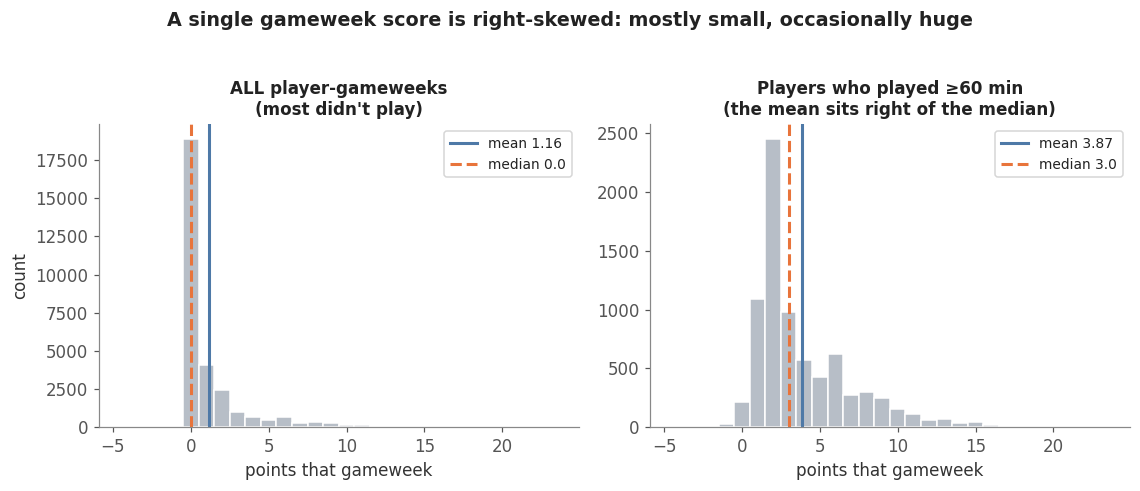

all: n=29,747 mean=1.16 median=0.0
played>=60min: n=7,738 mean=3.87 median=3.0 std=3.20


In [2]:
all_pts, played_pts = [], []
for g in GWS:
    for i in PTS[g]:
        all_pts.append(PTS[g][i])
        if MINS[g][i] >= 60:
            played_pts.append(PTS[g][i])
all_pts = np.array(all_pts); played_pts = np.array(played_pts)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
axes[0].hist(all_pts, bins=np.arange(-4, 25)-0.5, color=GREY, edgecolor='white')
axes[0].axvline(all_pts.mean(), color=MEAN_C, lw=2, label=f'mean {all_pts.mean():.2f}')
axes[0].axvline(np.median(all_pts), color=MED_C, lw=2, ls='--', label=f'median {np.median(all_pts):.1f}')
axes[0].set_title('ALL player-gameweeks\n(most didn\'t play)', fontsize=11)
axes[0].set_xlabel('points that gameweek'); axes[0].set_ylabel('count'); axes[0].legend(fontsize=9)

axes[1].hist(played_pts, bins=np.arange(-4, 25)-0.5, color=GREY, edgecolor='white')
axes[1].axvline(played_pts.mean(), color=MEAN_C, lw=2, label=f'mean {played_pts.mean():.2f}')
axes[1].axvline(np.median(played_pts), color=MED_C, lw=2, ls='--', label=f'median {np.median(played_pts):.1f}')
axes[1].set_title('Players who played ≥60 min\n(the mean sits right of the median)', fontsize=11)
axes[1].set_xlabel('points that gameweek'); axes[1].legend(fontsize=9)
fig.suptitle('A single gameweek score is right-skewed: mostly small, occasionally huge',
             fontsize=12.5, fontweight='bold', y=1.03)
plt.tight_layout(); plt.savefig('outputs/charts/01_distribution_shapes.png', bbox_inches='tight'); plt.show()
print(f"all: n={len(all_pts):,} mean={all_pts.mean():.2f} median={np.median(all_pts):.1f}")
print(f"played>=60min: n={len(played_pts):,} mean={played_pts.mean():.2f} median={np.median(played_pts):.1f} std={played_pts.std():.2f}")

**Reading it:** the right panel is the important one — even restricted to players who actually
played, the mean (blue) sits clearly to the right of the median (orange). That gap is entirely
made of occasional big hauls. This is the exact mechanism the rest of the story is about.

## 2. Zoom out to a 4-gameweek window: the two summaries genuinely disagree

Now build the actual feature: for every player likely to start (played ≥45 min/GW on
average over the past window), compare their past-4-GW **mean** points to their past-4-GW
**median** points. If mean and median always agreed, this chart would be one spike.

panel rows: 6,786  |  unique players: 406


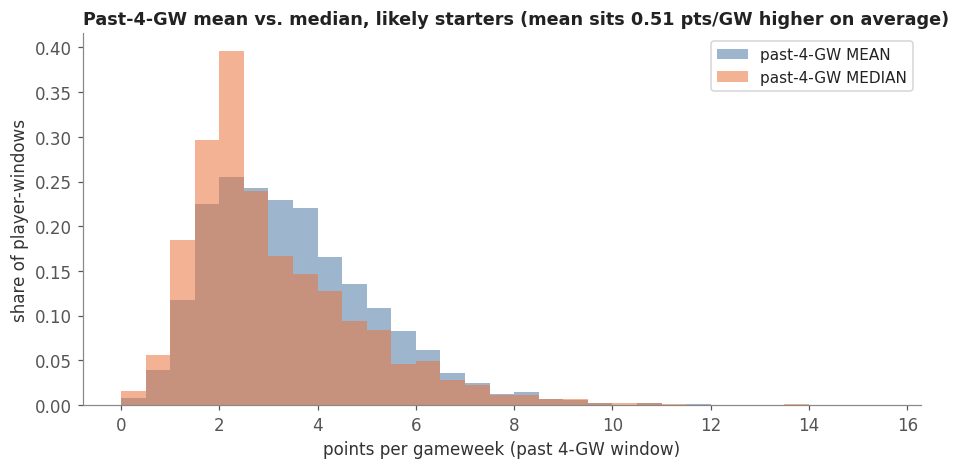

In [3]:
panel4 = build_panel(4)
print(f"panel rows: {len(panel4):,}  |  unique players: {panel4['pid'].nunique():,}")

fig, ax = plt.subplots(figsize=(8.6, 4.4))
bins = np.arange(0, 16, 0.5)
ax.hist(panel4['past_mean'], bins=bins, color=MEAN_C, alpha=0.55, label='past-4-GW MEAN', density=True)
ax.hist(panel4['past_median'], bins=bins, color=MED_C, alpha=0.55, label='past-4-GW MEDIAN', density=True)
ax.set_xlabel('points per gameweek (past 4-GW window)'); ax.set_ylabel('share of player-windows')
ax.legend(fontsize=10)
gap = (panel4['past_mean'] - panel4['past_median']).mean()
ax.set_title(f'Past-4-GW mean vs. median, likely starters (mean sits {gap:.2f} pts/GW higher on average)',
             loc='left', fontsize=11.5)
plt.tight_layout(); plt.savefig('outputs/charts/02_mean_vs_median_spread.png', bbox_inches='tight'); plt.show()

**Reading it:** the median distribution (orange) is spikier at low integers — a natural result
of taking the middle of only 4 numbers. The mean (blue) is smoother and shifted right, again
because a single big haul inside the window pulls the average up without changing the median at all.

## 3. The actual relationship each correlation number is summarizing

Here is the raw scatter behind the headline correlation figures: does a player's past-4-GW
mean (or median) line up with what they **actually scored** over the next 4 gameweeks?

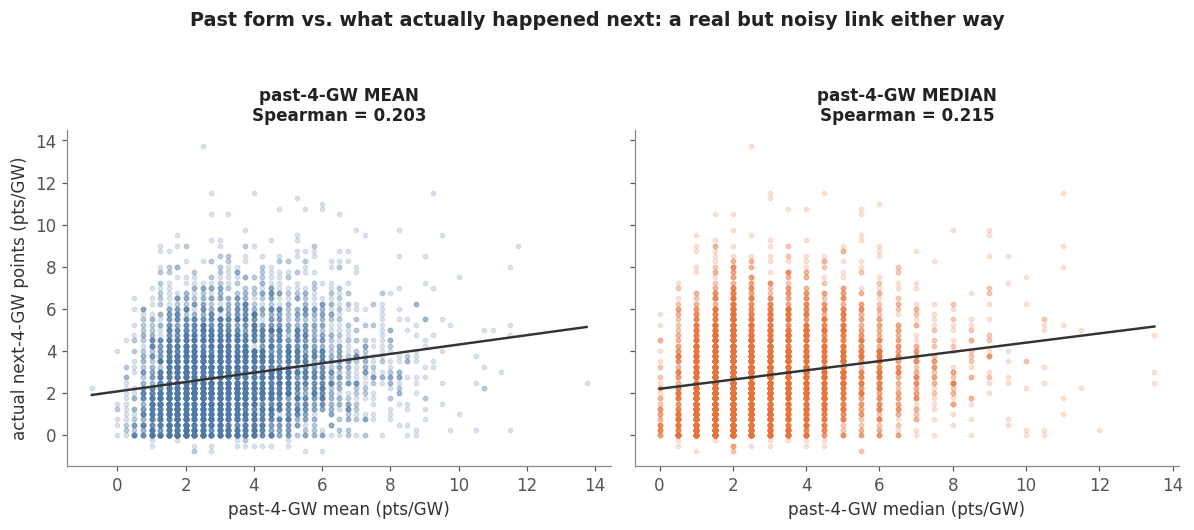

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
for ax, col, color, label in [
    (axes[0], 'past_mean', MEAN_C, 'MEAN'),
    (axes[1], 'past_median', MED_C, 'MEDIAN')]:
    ax.scatter(panel4[col], panel4['fwd_mean'], s=8, alpha=0.18, color=color)
    z = np.polyfit(panel4[col], panel4['fwd_mean'], 1)
    xs = np.linspace(panel4[col].min(), panel4[col].max(), 50)
    ax.plot(xs, np.polyval(z, xs), color='#333', lw=1.6)
    rho = spearmanr(panel4[col], panel4['fwd_mean']).correlation
    ax.set_title(f'past-4-GW {label}\nSpearman = {rho:.3f}', fontsize=11)
    ax.set_xlabel(f'past-4-GW {label.lower()} (pts/GW)')
axes[0].set_ylabel('actual next-4-GW points (pts/GW)')
fig.suptitle('Past form vs. what actually happened next: a real but noisy link either way',
             fontsize=12.5, fontweight='bold', y=1.04)
plt.tight_layout(); plt.savefig('outputs/charts/03_bivariate_scatter.png', bbox_inches='tight'); plt.show()

**Reading it:** both clouds are wide — recent form is a real signal, not a strong one, for either
statistic. At this horizon (N=4) the two trend lines are barely distinguishable, matching the
correlation numbers (0.203 vs 0.215) from the analysis stage.

## 4. Does one win at every horizon? No — it flips.

Repeating this comparison for windows of 4 to 8 gameweeks (walk-forward, GW-block bootstrap for
uncertainty) shows the two jobs disagree over time:

- **Ranking players** (what matters for transfer decisions): mean and median are statistically
  tied through N=6, and **mean pulls significantly ahead at N=7–8**.
- **Forecasting an exact points number**: **median is significantly more accurate at N=4 and N=6**,
  roughly tied elsewhere.

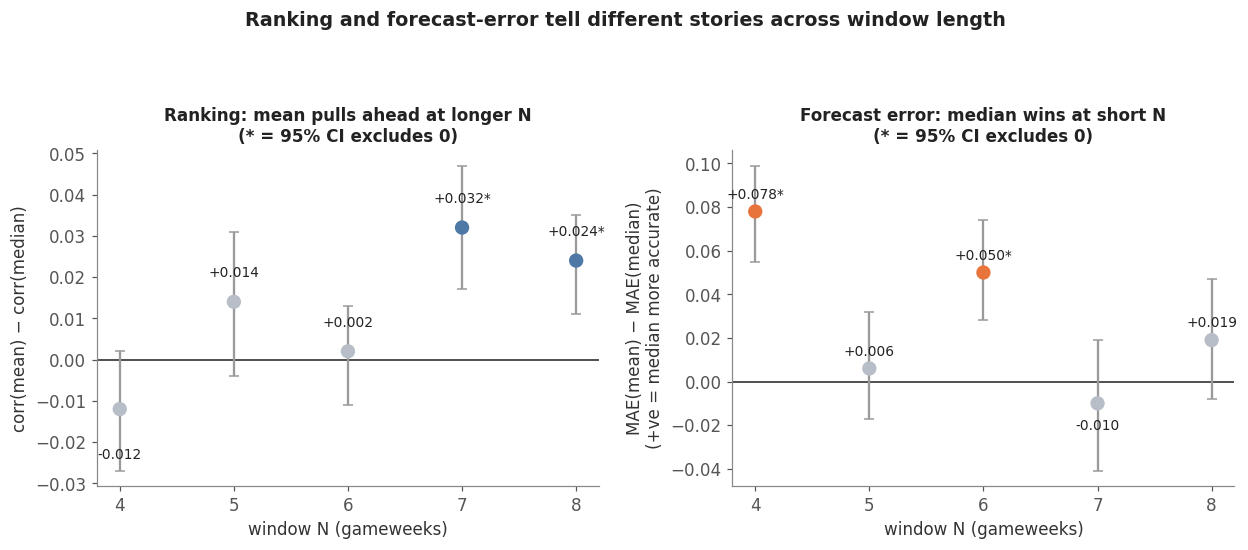

In [5]:
# ---- verified numbers (source: analysis-stage walk-forward screen, GW-block bootstrap, 2025/26) ----
Ns          = [4, 5, 6, 7, 8]
corr_mean   = [0.203, 0.225, 0.243, 0.261, 0.276]
corr_med    = [0.215, 0.211, 0.241, 0.229, 0.252]
corr_diff   = [m - d for m, d in zip(corr_mean, corr_med)]
corr_lo     = [-0.027, -0.004, -0.011, 0.017, 0.011]
corr_hi     = [0.002, 0.031, 0.013, 0.047, 0.035]

mae_mean    = [1.848, 1.709, 1.606, 1.521, 1.454]
mae_med     = [1.770, 1.703, 1.556, 1.531, 1.435]
# plot as MAE(mean) - MAE(median): +ve means median has the LOWER error (median more accurate)
mae_diff    = [m - d for m, d in zip(mae_mean, mae_med)]
mae_lo      = [0.055, -0.017, 0.028, -0.041, -0.008]
mae_hi      = [0.099, 0.032, 0.074, 0.019, 0.047]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
ax = axes[0]
sig = [lo > 0 or hi < 0 for lo, hi in zip(corr_lo, corr_hi)]
cols = [MEAN_C if (s and d > 0) else (MED_C if (s and d < 0) else GREY) for s, d in zip(sig, corr_diff)]
ax.axhline(0, color='#444', lw=1.2)
ax.errorbar(Ns, corr_diff, yerr=[np.array(corr_diff)-np.array(corr_lo), np.array(corr_hi)-np.array(corr_diff)],
            fmt='none', ecolor='#9a9a9a', capsize=3)
ax.scatter(Ns, corr_diff, s=70, c=cols, zorder=3)
for n, d, s in zip(Ns, corr_diff, sig):
    ax.text(n, d + (0.006 if d >= 0 else -0.012), f'{d:+.3f}' + ('*' if s else ''), ha='center', fontsize=9)
ax.set_xlabel('window N (gameweeks)'); ax.set_ylabel('corr(mean) − corr(median)')
ax.set_title('Ranking: mean pulls ahead at longer N\n(* = 95% CI excludes 0)', fontsize=11)
ax.set_xticks(Ns)

ax2 = axes[1]
sig2 = [lo > 0 or hi < 0 for lo, hi in zip(mae_lo, mae_hi)]
cols2 = [MED_C if (s and d > 0) else (MEAN_C if (s and d < 0) else GREY) for s, d in zip(sig2, mae_diff)]
ax2.axhline(0, color='#444', lw=1.2)
ax2.errorbar(Ns, mae_diff, yerr=[np.array(mae_diff)-np.array(mae_lo), np.array(mae_hi)-np.array(mae_diff)],
             fmt='none', ecolor='#9a9a9a', capsize=3)
ax2.scatter(Ns, mae_diff, s=70, c=cols2, zorder=3)
for n, d, s in zip(Ns, mae_diff, sig2):
    ax2.text(n, d + (0.006 if d >= 0 else -0.012), f'{d:+.3f}' + ('*' if s else ''), ha='center', fontsize=9)
ax2.set_xlabel('window N (gameweeks)'); ax2.set_ylabel('MAE(mean) − MAE(median)\n(+ve = median more accurate)')
ax2.set_title('Forecast error: median wins at short N\n(* = 95% CI excludes 0)', fontsize=11)
ax2.set_xticks(Ns)
fig.suptitle('Ranking and forecast-error tell different stories across window length',
             fontsize=12.5, fontweight='bold', y=1.08)
plt.tight_layout(); plt.savefig('outputs/charts/04_ranking_and_error_by_N.png', bbox_inches='tight'); plt.show()

## 5. It's not even the same story for every position

Pooling all positions together hides something: **midfielders** drive almost the entire median
advantage. Defenders, forwards, and keepers barely show a pattern.

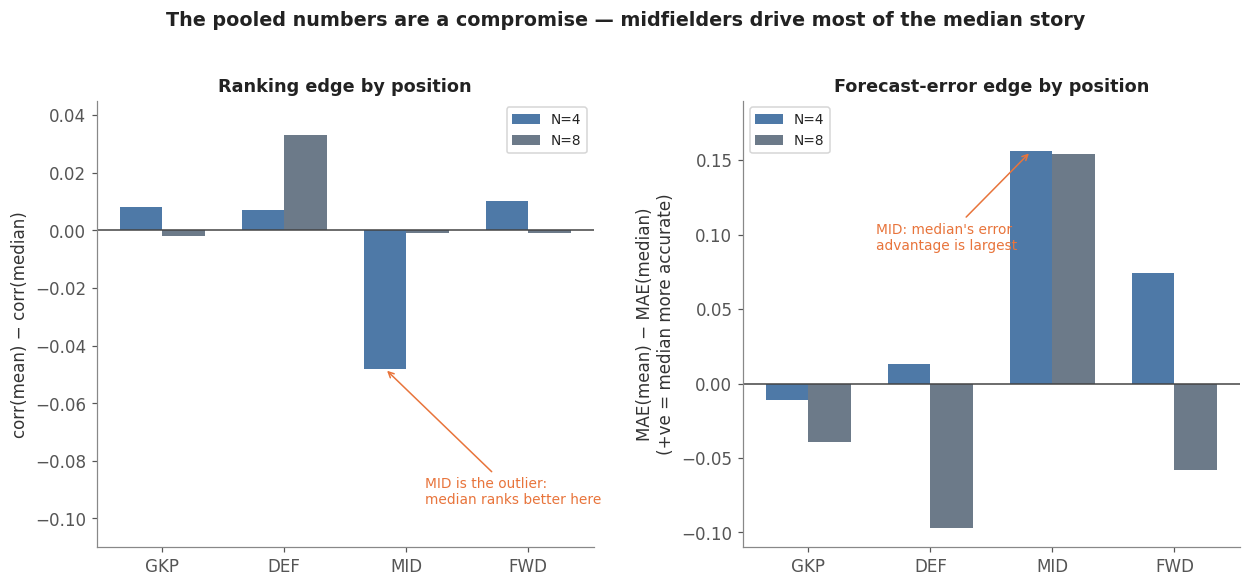

In [6]:
# ---- verified numbers (source: analysis-stage position-stratified screen, N=4 and N=8) ----
pos_names   = ['GKP', 'DEF', 'MID', 'FWD']
corr_diff_4 = [0.008, 0.007, -0.048, 0.010]   # mean - median, N=4
corr_diff_8 = [-0.002, 0.033, -0.001, -0.001] # N=8
mae_diff_4  = [-0.011, 0.013, 0.156, 0.074]   # median - mean, N=4 (+ve = median better)
mae_diff_8  = [-0.039, -0.097, 0.154, -0.058] # N=8

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2))
x = np.arange(4); w = 0.35
ax = axes[0]
ax.bar(x - w/2, corr_diff_4, width=w, color=MEAN_C, label='N=4')
ax.bar(x + w/2, corr_diff_8, width=w, color=MUTED, label='N=8')
ax.axhline(0, color='#444', lw=1)
ax.set_xticks(x); ax.set_xticklabels(pos_names)
ax.set_ylabel('corr(mean) − corr(median)')
ax.set_title('Ranking edge by position', fontsize=11.5)
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(-0.11, 0.045)
ax.annotate('MID is the outlier:\nmedian ranks better here',
            xy=(2 - w/2, -0.048), xytext=(2.15, -0.095), fontsize=9, color=MED_C,
            arrowprops=dict(arrowstyle='->', color=MED_C))

ax2 = axes[1]
ax2.bar(x - w/2, mae_diff_4, width=w, color=MEAN_C, label='N=4')
ax2.bar(x + w/2, mae_diff_8, width=w, color=MUTED, label='N=8')
ax2.axhline(0, color='#444', lw=1)
ax2.set_xticks(x); ax2.set_xticklabels(pos_names)
ax2.set_ylabel('MAE(mean) − MAE(median)\n(+ve = median more accurate)')
ax2.set_title('Forecast-error edge by position', fontsize=11.5)
ax2.legend(fontsize=9, loc='upper left')
ax2.set_ylim(-0.11, 0.19)
ax2.annotate("MID: median's error\nadvantage is largest",
            xy=(2 - w/2, 0.156), xytext=(0.55, 0.09), fontsize=9, color=MED_C,
            arrowprops=dict(arrowstyle='->', color=MED_C))
fig.suptitle('The pooled numbers are a compromise — midfielders drive most of the median story',
             fontsize=12.5, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('outputs/charts/05_position_breakdown.png', bbox_inches='tight'); plt.show()

## 6. Why does median ever win? It's the hauls, not the median.

If median were a genuinely better statistic, capping rare big scores in the past window
shouldn't change anything. But it does — capping past scores at 10 points **erases almost
all of the median's forecast-error advantage**. That confirms the mean isn't "wrong"; it's just
unguarded against one-off hauls that don't repeat.

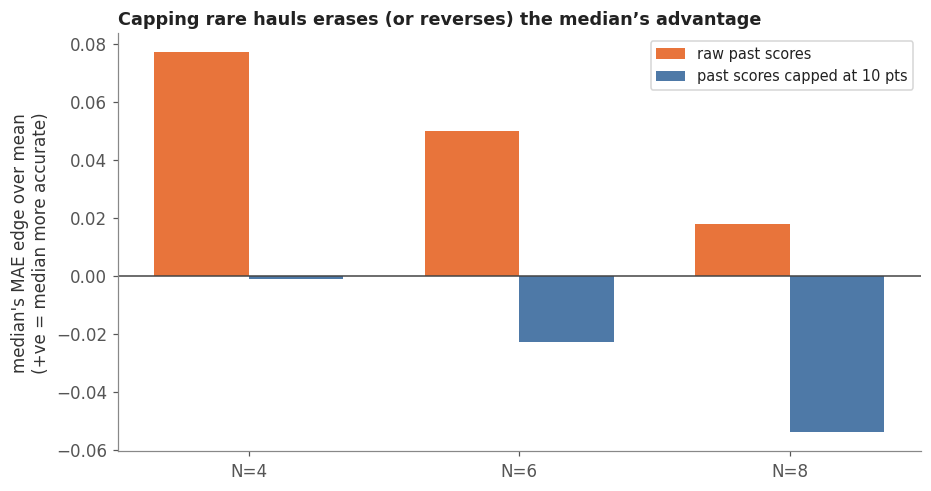

In [7]:
# ---- verified numbers (source: analysis-stage haul-capping sensitivity check) ----
# "edge" = MAE(mean) - MAE(median); +ve means median is more accurate than mean.
Ns2       = [4, 6, 8]
raw_diff  = [0.077, 0.050, 0.018]     # uncapped: median clearly more accurate
cap_diff  = [-0.001, -0.023, -0.054]  # capped at 10 pts: median's edge vanishes / flips to mean

fig, ax = plt.subplots(figsize=(8.6, 4.6))
x = np.arange(3); w = 0.35
ax.bar(x - w/2, raw_diff, width=w, color=MED_C, label='raw past scores')
ax.bar(x + w/2, cap_diff, width=w, color=MEAN_C, label='past scores capped at 10 pts')
ax.axhline(0, color='#444', lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'N={n}' for n in Ns2])
ax.set_ylabel("median's MAE edge over mean\n(+ve = median more accurate)")
ax.set_title('Capping rare hauls erases (or reverses) the median’s advantage', loc='left', fontsize=11.5)
ax.legend(fontsize=9.5)
plt.tight_layout(); plt.savefig('outputs/charts/06_mechanism_capping.png', bbox_inches='tight'); plt.show()

## The big lesson

**Mean vs median isn't a single, context-free choice — it depends on the job and the horizon.**

- For **ranking players** at the engine's actual 4-gameweek horizon (what drives transfer
  decisions): mean and median are a **statistical tie**. No reason to change the current rule.
- For **forecasting an exact expected-points number**: median is measurably more accurate at
  short windows, but only because the **raw mean is unguarded against rare hauls** —
  especially for midfielders. A capped/winsorized mean would likely capture the best of both,
  though that's a next step, not something tested here.

**Recommendation:** keep the engine's current mean-based ranking rule at N=4 unchanged. If a
future version needs an exact points forecast rather than just a rank, cap extreme past-window
scores (e.g. at 10 points) before averaging, rather than switching to a plain median.

---
*Caveats: one season (2025/26), a census not a sample — whether this pattern holds in other
seasons is untested. Results are links, not causes. The "likely starter" gate (≥45 min/GW)
and the position mix both affect the size of these effects — see the analysis-stage handoff
for the full sensitivity checks.*